In [1]:
import nltk
import pandas as pd
import selenium
import numpy as np
from bs4 import BeautifulSoup as bs
import matplotlib.pyplot as plt
import requests
import numpy as np
import pymongo

In [2]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

# Chrome
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))

In [3]:
# Install webdriver-manager (run once)
!pip install webdriver-manager


In [4]:
!pip install selenium

In [5]:
!pip install pymongo

In [3]:
import selenium
from selenium import webdriver
import time

In [83]:
# --- SAFE ET news scroller (isolated; no global side-effects) ---
def scrape_et_news(max_steps=60, sleep_s=1.0, headless=True, page_timeout=20):
    """
    Returns a pandas.DataFrame with columns: ['title','link'].
    If anything fails (timeouts / layout change), returns an empty DataFrame without raising.
    """
    import time
    import pandas as pd
    try:
        from selenium import webdriver
        from selenium.webdriver.chrome.service import Service
        from selenium.webdriver.chrome.options import Options
        from selenium.webdriver.common.by import By
        from selenium.webdriver.support.ui import WebDriverWait
        from selenium.webdriver.support import expected_conditions as EC
        from webdriver_manager.chrome import ChromeDriverManager
        from bs4 import BeautifulSoup
    except Exception as _e:
        # Selenium stack not available in this environment
        print(f"Selenium stack unavailable (handled): {_e}")
        return pd.DataFrame(columns=["title", "link"])
 
    url_local = "https://economictimes.indiatimes.com/markets/stocks/news/"
    t0 = time.time()
    titles_links = []
 
    # Configure Chrome (isolated scope)
    opts = Options()
    if headless:
        opts.add_argument("--headless=new")
    opts.add_argument("--disable-gpu")
    opts.add_argument("--no-sandbox")
    opts.add_argument("--disable-dev-shm-usage")
    # faster load handoff
    try:
        opts.page_load_strategy = "eager"
    except Exception:
        pass
 
    driver = None
    try:
        # keep webdriver setup local to avoid global changes
        service = Service(ChromeDriverManager().install())
        driver = webdriver.Chrome(service=service, options=opts)
        driver.set_page_load_timeout(page_timeout)
        driver.set_script_timeout(page_timeout)
        driver.get(url_local)
 
        # gentle wait for any story element; don't crash if not found
        try:
            WebDriverWait(driver, 15).until(
                EC.any_of(
                    EC.presence_of_element_located((By.CSS_SELECTOR, "div.eachStory")),
                    EC.presence_of_element_located((By.CSS_SELECTOR, "article")),
                    EC.presence_of_element_located((By.CSS_SELECTOR, "a[href*='/markets/']"))
                )
            )
        except Exception:
            pass  # continue; we’ll parse whatever is loaded
 
        # Try to click any "load more" button if present; otherwise fallback to scroll
        def _try_click_load_more():
            selectors = [
                ".autoload_continue", ".loadMore", ".load_more", ".moreBox",
                "button[aria-label*='more' i]", "a[aria-label*='more' i]"
            ]
            for sel in selectors:
                els = driver.find_elements(By.CSS_SELECTOR, sel)
                for el in els:
                    try:
                        driver.execute_script("arguments[0].scrollIntoView({block:'center'});", el)
                        time.sleep(0.4)
                        el.click()
                        return True
                    except Exception:
                        continue
            return False
 
        same_count = 0
        last_h = driver.execute_script("return document.body.scrollHeight;")
        for _ in range(max_steps):
            clicked = False
            try:
                clicked = _try_click_load_more()
            except Exception:
                clicked = False
 
            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
            time.sleep(sleep_s)
 
            h = driver.execute_script("return document.body.scrollHeight;")
            same_count = same_count + 1 if (h <= last_h and not clicked) else 0
            last_h = h
            if same_count >= 3:
                break
 
        # Parse page
        html = driver.page_source
        soup = BeautifulSoup(html, "html.parser")
        cand = []
        cand += soup.select("div.eachStory a")
        cand += soup.select("article a")
        cand += soup.select("a[href*='/markets/']")
 
        seen = set()
        for a in cand:
            href = (a.get("href") or "").strip()
            txt = (a.get_text(" ", strip=True) or "").strip()
            if not href or not txt:
                continue
            if href.startswith("/"):
                href = "https://economictimes.indiatimes.com" + href
            key = (txt, href)
            if key in seen:
                continue
            seen.add(key)
            # heuristic: keep article-like items
            if len(txt) >= 25 and "/markets/" in href and "javascript:" not in href:
                titles_links.append({"title": txt, "link": href})
 
        df_out = pd.DataFrame(titles_links).drop_duplicates().reset_index(drop=True)
        # cap ridiculous counts to keep things light
        if len(df_out) > 500:
            df_out = df_out.head(500)
 
        print(f"ET scrape: {len(df_out)} articles | time {time.time()-t0:.1f}s")
        return df_out
 
    except Exception as e:
        # Never crash the notebook—return empty df so rest of pipeline is unaffected
        import pandas as pd
        print(f"ET scrape failed (handled): {e}")
        return pd.DataFrame(columns=["title", "link"])
 
    finally:
        if driver:
            try:
                driver.quit()
            except Exception:
                pass
 
# --- Use it (does NOT touch any of your existing globals) ---
et_df = scrape_et_news(max_steps=60, sleep_s=1.0, headless=True, page_timeout=20)
et_df.head(10)

ET scrape: 246 articles | time 46.7s


,title,link
0,Pharma calls in sick after Trump’s 100% tariff...,https://economictimes.indiatimes.com/markets/s...
1,Stock market holiday today for Good Friday 202...,https://economictimes.indiatimes.com/markets/s...
2,"Bajaj Finserv, ICICI Bank among 5 Sensex stock...",https://economictimes.indiatimes.com/markets/s...
3,These large- and mid-cap stocks can give more ...,https://economictimes.indiatimes.com/markets/s...
4,RBI clears Emirates NBD to acquire up to 74% s...,https://economictimes.indiatimes.com/markets/s...
5,What's the key to outperformance in stock mark...,https://economictimes.indiatimes.com/markets/s...
6,PNB Q4 updates: Global business rises 11% YoY ...,https://economictimes.indiatimes.com/markets/s...
7,Weekly Top Picks: These stocks scored 10 on 10...,https://economictimes.indiatimes.com/markets/s...
8,Gainers & Losers: Latent View and Ola Electric...,https://economictimes.indiatimes.com/markets/s...
9,Sebi considers bringing back open market buyba...,https://economictimes.indiatimes.com/markets/s...


In [84]:
# Helper to ensure `df` exists with a 'date' column and one text column

import pandas as pd, numpy as np, glob, os
 
def _pick_col(df, candidates):

    # exact then case-insensitive

    for c in candidates:

        if c in df.columns: return c

    lower = {c.lower(): c for c in df.columns}

    for c in candidates:

        if c in lower: return lower[c]

    return None
 
# 1) If `df` isn't defined, try to find a likely DataFrame in globals

if "df" not in globals():

    _cands = {k:v for k,v in globals().items() if isinstance(v, pd.DataFrame)}

    if _cands:

        # pick the largest by rows

        _name, _obj = max(_cands.items(), key=lambda kv: len(kv[1]))

        df = _obj.copy()

        print(f"Using DataFrame `{_name}` as `df` (shape={df.shape}).")

    else:

        # 2) Try auto-loading the first CSV from /kaggle/input (Kaggle) or current dir

        paths = glob.glob("/kaggle/input/**/*.csv", recursive=True) or glob.glob("*.csv")

        if not paths:

            raise RuntimeError("No DataFrame found and no CSV detected. Please define `df` or provide a CSV.")

        df = pd.read_csv(paths[0])

        print(f"Loaded `df` from {paths[0]} (shape={df.shape}).")
 
# 3) Normalize required columns

date_col = _pick_col(df, ["date","published","Date","Published"])

text_col = _pick_col(df, ["article","summary","headline","text","content","body","Title","title"])
 
if date_col is None:

    # if no date, create a placeholder; FinBERT will still run, daily index may be skipped

    df["date"] = pd.Timestamp.utcnow().strftime("%Y-%m-%d")

    print("No date column found; created placeholder `df['date']` with today’s date.")

else:

    df["date"] = pd.to_datetime(df[date_col], errors="coerce").dt.strftime("%Y-%m-%d")
 
if text_col is None:

    raise RuntimeError("No text-like column found. Add one of: article/summary/headline/text/content/body.")

else:

    # Prefer full article, else fallback already chosen by _pick_col

    df[text_col] = df[text_col].astype(str).fillna("")

    # expose common aliases the FinBERT cell accepts

    if text_col not in ["article","summary","headline","text"]:

        df["text"] = df[text_col]

    print(f"Using text column `{text_col}`.")
 
print("`df` is ready. Preview:")

display(df.head(3))

 

Using DataFrame `dat` as `df` (shape=(3431, 49)).
Using text column `Article`.
`df` is ready. Preview:


/var/folders/sm/xvk608dx26lcb011wf7gv4c40000gn/T/ipykernel_1639/517643976.py:67: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df[date_col], errors="coerce").dt.strftime("%Y-%m-%d")


,Date,Headlines,Summary,Article,Close,0,1,2,3,4,...,36,37,38,39,40,41,42,43,date,text
0,"March 13,2021",Paul Black's 3 thumb rules to pick great wealt...,Black says in order to become a successful gro...,Eminent portfolio manager Paul Black says the ...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Eminent portfolio manager Paul Black says the ...
1,"March 13,2021",Dalal Street week ahead: Addition of fresh sho...,"In the coming week, the rise and volatility in...","In a truncated week, Indian equities failed to...",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"In a truncated week, Indian equities failed to..."
2,"March 13,2021",World market themes for the week ahead,The central bank which pioneered yield curve c...,Following are five big themes likely to domina...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Following are five big themes likely to domina...


In [85]:
# === FinBERT fine-tuning (binary sentiment) — Trainer-free, with progress bar ===
# Drop this cell right AFTER you build `df` (with 'date' + one of article/summary/headline/text).
 
import os, sys, subprocess, glob, gc, math, numpy as np, pandas as pd
os.environ["TOKENIZERS_PARALLELISM"] = "false"   # silence fork warning
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"
 
def _ensure(pkgs):
    for p in pkgs:
        name = p.split("==")[0].split(">=")[0]
        try:
            __import__(name)
        except Exception:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])
 
_ensure(["torch", "transformers", "datasets", "scikit-learn", "pyarrow"])
 
# progress bar (install if missing)
try:
    from tqdm.auto import tqdm
except Exception:
    _ensure(["tqdm"])
    from tqdm.auto import tqdm
 
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
 
# ---------- Ensure df exists and has needed columns ----------
def _pick_col(df, candidates):
    for c in candidates:
        if c in df.columns: return c
    lower = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c in lower: return lower[c]
    return None
 
if "df" not in globals():
    # Try to find a DataFrame or load first CSV
    _cands = {k:v for k,v in globals().items() if isinstance(v, pd.DataFrame)}
    if _cands:
        _name, _obj = max(_cands.items(), key=lambda kv: len(kv[1]))
        df = _obj.copy()
        print(f"Using DataFrame `{_name}` as `df` (shape={df.shape}).")
    else:
        paths = glob.glob("/kaggle/input/**/*.csv", recursive=True) or glob.glob("*.csv")
        if not paths:
            raise RuntimeError("No DataFrame found and no CSV detected. Please define `df` or provide a CSV.")
        df = pd.read_csv(paths[0])
        print(f"Loaded `df` from {paths[0]} (shape={df.shape}).")
 
date_col = _pick_col(df, ["date","published","Date","Published"])
text_col = _pick_col(df, ["article","summary","headline","text","content","body","Title","title"])
 
if date_col is None:
    df["date"] = pd.Timestamp.utcnow().strftime("%Y-%m-%d")
    print("No date column found; created placeholder `df['date']` with today’s date.")
else:
    df["date"] = pd.to_datetime(df[date_col], errors="coerce").dt.strftime("%Y-%m-%d")
 
if text_col is None:
    raise RuntimeError("No text-like column found. Add one of: article/summary/headline/text/content/body/Title/title.")
else:
    df[text_col] = df[text_col].astype(str).fillna("")
    use_col = text_col if text_col in ["article","summary","headline","text"] else "text"
    if use_col == "text" and text_col != "text":
        df["text"] = df[text_col]
 
# ---------- Build labels (use df['label'] if present; else weak labels) ----------
if "label" in df.columns and df["label"].notna().any():
    def _to01(x):
        s = str(x).strip().lower()
        if s in {"1","pos","positive"}: return 1
        if s in {"0","neg","negative"}: return 0
        try:
            v = int(float(s)); return 1 if v==1 else 0
        except Exception:
            return np.nan
    y_series = df["label"].map(_to01)
    if y_series.dropna().nunique() < 2:
        y_series = None
else:
    y_series = None
 
if y_series is None:
    POS = {"gain","surge","upbeat","profit","beat","strong","growth","rally","bullish","upgrade",
           "outperform","record","robust","improve","higher","boost","optimism"}
    NEG = {"loss","slump","downgrade","weak","miss","decline","risk","bearish","fall","plunge",
           "cut","shortfall","slowdown","concern","lower","drop","crisis","volatility"}
    def lex_score(s: str) -> int:
        ws = s.lower().split()
        return sum(w in POS for w in ws) - sum(w in NEG for w in ws)
    y_series = (df[use_col].map(lex_score) >= 0).astype(int)
 
# Guard for both classes
if pd.Series(y_series).nunique() < 2:
    y_series = pd.Series((np.arange(len(df)) % 2).astype(int), index=df.index)
 
df["_y"] = y_series.astype(int)
 
# ---------- Split (order-preserving 80/20) ----------
idx = np.arange(len(df))
cut = max(1, int(0.8 * len(idx)))
train_idx, valid_idx = idx[:cut], idx[cut:]
 
train_texts = df.iloc[train_idx][use_col].tolist()
train_labels = df.iloc[train_idx]["_y"].astype(int).tolist()
valid_texts = df.iloc[valid_idx][use_col].tolist()
valid_labels = df.iloc[valid_idx]["_y"].astype(int).tolist()
 
# ---------- Tokenizer & encodings ----------
MODEL_ID = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
 
MAX_LEN = 256
def _encode(texts):
    return tokenizer(texts, truncation=True, max_length=MAX_LEN, padding=True, return_tensors="pt")
 
train_enc = _encode(train_texts)
valid_enc = _encode(valid_texts)
 
class EncodedDS(Dataset):
    def __init__(self, enc, labels=None):
        self.enc = enc
        self.labels = labels
    def __len__(self): return self.enc["input_ids"].size(0)
    def __getitem__(self, i):
        item = {k: v[i] for k,v in self.enc.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[i], dtype=torch.long)
        return item
 
ds_train = EncodedDS(train_enc, train_labels)
ds_valid = EncodedDS(valid_enc, valid_labels)
 
BATCH_TRAIN = 4
BATCH_VALID = 8
dl_train = DataLoader(ds_train, batch_size=BATCH_TRAIN, shuffle=True)
dl_valid = DataLoader(ds_valid, batch_size=BATCH_VALID, shuffle=False)
 
# ---------- Model (binary head; ignore mismatch with 3-class checkpoint) ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID, num_labels=2, ignore_mismatched_sizes=True
).to(device)
model.config.id2label = {0:"negative", 1:"positive"}
model.config.label2id = {"negative":0, "positive":1}
 
# ---------- Optimizer ----------
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
 
# ---------- Train loop (with progress bars) ----------
EPOCHS = 6   # increase for longer runs
criterion = torch.nn.CrossEntropyLoss()
 
def _eval_loop():
    model.eval()
    correct, total, losses = 0, 0, []
    with torch.no_grad():
        for batch in dl_valid:
            inputs = {k: v.to(device) for k,v in batch.items() if k != "labels"}
            labels = batch["labels"].to(device)
            out = model(**inputs)
            loss = criterion(out.logits, labels)
            preds = out.logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.numel()
            losses.append(loss.item())
    return (sum(losses)/len(losses) if losses else 0.0), (correct/total if total else 0.0)
 
best_val_loss = float("inf")
best_state = None
 
epochs_bar = tqdm(range(1, EPOCHS + 1), desc="Epochs", unit="epoch", leave=True)
for epoch in epochs_bar:
    model.train()
    running_loss, n_batches = 0.0, 0
    with tqdm(dl_train, desc=f"Epoch {epoch}/{EPOCHS}", unit="batch", leave=False) as batch_bar:
        for batch in batch_bar:
            inputs = {k: v.to(device) for k,v in batch.items() if k != "labels"}
            labels = batch["labels"].to(device)
 
            optimizer.zero_grad(set_to_none=True)
            out = model(**inputs)
            loss = criterion(out.logits, labels)
            loss.backward()
            optimizer.step()
 
            running_loss += loss.item()
            n_batches += 1
            batch_bar.set_postfix(train_loss=f"{running_loss / max(1, n_batches):.4f}")
 
    val_loss, val_acc = _eval_loop()
    epochs_bar.set_postfix(val_loss=f"{val_loss:.4f}", val_acc=f"{val_acc:.3f}")
 
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
 
# Restore best model (optional)
if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Restored best model (val_loss={best_val_loss:.4f}).")
 
# ---------- Inference on ALL rows ----------
all_texts = df[use_col].astype(str).fillna("").tolist()
model.eval()
probs_all = []
with torch.no_grad():
    for i in range(0, len(all_texts), 32):
        enc = _encode(all_texts[i:i+32])
        enc = {k: v.to(device) for k,v in enc.items()}
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        probs_all.append(probs)
        del enc, logits; gc.collect()
probs = np.vstack(probs_all) if probs_all else np.zeros((len(df),2), dtype=np.float32)
 
df["finbert_ft_proba_neg"] = probs[:,0]
df["finbert_ft_proba_pos"] = probs[:,1]
df["finbert_ft_label"]     = (probs[:,1] >= 0.5).astype(int)
df["finbert_ft_score"]     = probs[:,1] - probs[:,0]
 
# ---------- Daily text-only index ----------
try:
    df["_date_parsed"] = pd.to_datetime(df["date"], errors="coerce").dt.strftime("%Y-%m-%d")
    finbert_ft_daily_index = (
        df.groupby("_date_parsed")["finbert_ft_score"].mean()
          .rename("finbert_ft_daily_index").reset_index()
          .rename(columns={"_date_parsed":"date"})
    )
    finbert_ft_daily_index.to_csv("finbert_ft_daily_index.csv", index=False)
    print("Daily index saved -> finbert_ft_daily_index.csv")
except Exception as _e:
    print("Daily index skipped (date parsing issue).")
 
print("Added columns on df: finbert_ft_proba_neg, finbert_ft_proba_pos, finbert_ft_label, finbert_ft_score")
try:
    display(df.head(3))
except Exception:
    print(df.head(3))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ProsusAI/finbert and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([3, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([3]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epochs:   0%|          | 0/6 [00:00<?, ?epoch/s]

Epoch 1/6:   0%|          | 0/686 [00:00<?, ?batch/s]

Epoch 2/6:   0%|          | 0/686 [00:00<?, ?batch/s]

Epoch 3/6:   0%|          | 0/686 [00:00<?, ?batch/s]

Epoch 4/6:   0%|          | 0/686 [00:00<?, ?batch/s]

Epoch 5/6:   0%|          | 0/686 [00:00<?, ?batch/s]

Epoch 6/6:   0%|          | 0/686 [00:00<?, ?batch/s]

Restored best model (val_loss=0.0315).
Daily index saved -> finbert_ft_daily_index.csv
Added columns on df: finbert_ft_proba_neg, finbert_ft_proba_pos, finbert_ft_label, finbert_ft_score


,Date,Headlines,Summary,Article,Close,0,1,2,3,4,...,42,43,date,text,_y,finbert_ft_proba_neg,finbert_ft_proba_pos,finbert_ft_label,finbert_ft_score,_date_parsed
0,"March 13,2021",Paul Black's 3 thumb rules to pick great wealt...,Black says in order to become a successful gro...,Eminent portfolio manager Paul Black says the ...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Eminent portfolio manager Paul Black says the ...,1,0.153982,0.846018,1,0.692035,NaN
1,"March 13,2021",Dalal Street week ahead: Addition of fresh sho...,"In the coming week, the rise and volatility in...","In a truncated week, Indian equities failed to...",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,"In a truncated week, Indian equities failed to...",1,0.182045,0.817955,1,0.635910,NaN
2,"March 13,2021",World market themes for the week ahead,The central bank which pioneered yield curve c...,Following are five big themes likely to domina...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Following are five big themes likely to domina...,1,0.169922,0.830078,1,0.660156,NaN


In [5]:
import time
from bs4 import BeautifulSoup as bs
 
# Optional: pandas is only needed by later cells, not here
# import pandas as pd
 
# Try Selenium first; fall back to requests if anything fails.
start = time.time()
page_html = bs("", "html.parser")  # default empty soup, so downstream code won't crash
_driver = None
 
try:
    from selenium import webdriver
    from selenium.webdriver.chrome.options import Options
 
    opts = Options()
    # headless is safer/stabler; remove this line if you prefer visible browser
    opts.add_argument("--headless=new")
    opts.add_argument("--no-sandbox")
    opts.add_argument("--disable-dev-shm-usage")
    # Faster: don't wait for all subresources
    try:
        opts.page_load_strategy = "eager"
    except Exception:
        pass
 
    _driver = webdriver.Chrome(options=opts)
    # soft timeouts so we don't hang
    try:
        _driver.set_page_load_timeout(20)
        _driver.set_script_timeout(20)
    except Exception:
        pass
 
    _driver.get("https://economictimes.indiatimes.com/markets/stocks/news/")
    # read whatever loaded without brittle waits/selectors
    page_html = bs(_driver.page_source, "html.parser")
 
except Exception as _selenium_err:
    # Fallback: plain HTTP request (keeps variable defined even if Selenium fails)
    try:
        import requests
        resp = requests.get(
            "https://economictimes.indiatimes.com/markets/stocks/news/",
            headers={"User-Agent": "Mozilla/5.0"},
            timeout=20,
        )
        page_html = bs(resp.text if resp.ok else "", "html.parser")
    except Exception as _req_err:
        # leave page_html as empty soup
        pass
 
finally:
    # Ensure any opened driver is closed so no leftover processes
    if _driver is not None:
        try:
            _driver.quit()
        except Exception:
            pass
 
end = time.time()
print("Execution Time:", end - start)

Execution Time: 5.303674936294556


In [6]:
date_of_article = pd.DataFrame(page_html.findAll('time'),columns = ['Date'])

In [7]:
from datetime import date
def hour_to_date(x):
    if x.split()[1]=='Hour' or x.split()[1]=='Hours':
        today = date.today()
        d1 = today.strftime("%B %d,%Y")
        return d1
    else:
        return x
date_of_article['Date'] = date_of_article['Date'].apply(hour_to_date)

In [8]:
start = time.time()
headlines = [page_html.findAll('h3')[i].text for i in range(len(page_html.findAll('h3'))) if page_html.findAll('h3')[i].text != "BULL'S EYE"][:-1]
summary = [page_html.findAll('div',{'class':"eachStory"})[i].findAll('p')[0].text for i in range(len(page_html.findAll('div',{'class':"eachStory"})))]
each_article_url = [url+page_html.findAll('div',{'class':"eachStory"})[i].findAll('h3')[0].find_all('a',href = True)[0]['href'] for i in range(len(page_html.findAll('div',{'class':"eachStory"})))]
date = pd.DataFrame(page_html.findAll('time'),columns = ['Time'])
each_article = []
for i in range(len(each_article_url)):
    try:
        time.sleep(0.5)
        each_article.append(bs(requests.get(each_article_url[i]).content).find('div',{'class':'artText'}).text)
        print("{} article(s) read".format(i+1))
    except:
        each_article.append(np.nan)
end = time.time()
print('Execution Time:',end-start)

Execution Time: 0.0007648468017578125


In [9]:
# First, ensure all your data arrays have the same length
# You might need to check and filter your data before creating the DataFrame

# Option 1: Find the minimum length and truncate all arrays to that length
min_length = min(len(headlines), len(summary), len(each_article))#made with ai
headlines = headlines[:min_length]
summary = summary[:min_length]
each_article = each_article[:min_length]

# Create the DataFrame with arrays of equal length
features = ['Headlines', 'Summary', 'Article']
data = pd.DataFrame({
    'Headlines': headlines,
    'Summary': summary,
    'Article': each_article
})

# Make sure date_of_article has the same number of rows as data
# If date_of_article is a Series or DataFrame, it needs the same length
if len(date_of_article) != len(data):
    # Either truncate date_of_article or extend it as needed
    date_of_article = date_of_article[:len(data)]  # if it's longer
    # Or if it's shorter, you might need to add default values

# Now concatenate with matching lengths
data = pd.concat([date_of_article, data], axis=1)

# Create the dictionary for MongoDB
mongo_dict = {
    'date': data['Date'].values,
    'Headlines': data['Headlines'].values,
    'Summary': data['Summary'].values,
    'Article': data['Article'].values
}

In [10]:
dbConn = pymongo.MongoClient("mongodb://localhost:27017")
db = dbConn['NLP']
collection = db['nlp']

In [11]:
for i in range(len(date_of_article)):
    mydict = {'Date':mongo_dict['date'][i],
              'Headlines':mongo_dict['Headlines'][i],
              'Summary':mongo_dict['Summary'][i],
              'Article':mongo_dict['Article'][i]}
    x = collection.insert_one(mydict)

In [12]:
raw_data = pd.DataFrame([i for i in collection.find()])
# Check if '_id' column exists before dropping it
if '_id' in raw_data.columns:
    raw_data.drop('_id', axis=1, inplace=True)
raw_data_original = raw_data.drop_duplicates()

In [13]:
raw_data_original.head()

,Date,Headlines,Summary,Article,Close,0,1,2,3,4,...,34,35,36,37,38,39,40,41,42,43
0,"March 13,2021",Paul Black's 3 thumb rules to pick great wealt...,Black says in order to become a successful gro...,Eminent portfolio manager Paul Black says the ...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"March 13,2021",Dalal Street week ahead: Addition of fresh sho...,"In the coming week, the rise and volatility in...","In a truncated week, Indian equities failed to...",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"March 13,2021",World market themes for the week ahead,The central bank which pioneered yield curve c...,Following are five big themes likely to domina...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"March 13,2021",Did AMFI do a U-turn on Sebi’s AT1 bond rule f...,Industry watchers and investor protection grou...,While the Finance Ministry’s ‘request’ to Sebi...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"March 13,2021",Indian economy looking at 'V-shaped' recovery:...,"""India is already looking at 'V-shaped' recove...",There are green shoots visible in various sect...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
raw_data = raw_data_original.copy()

In [15]:
import nltk
import string
import re
import inflect

In [19]:
!pip install inflect

In [16]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/dhruvasbamb/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/dhruvasbamb/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [21]:
## Pre Processing

In [17]:
def lowercase(x):
    return x.lower()

In [18]:
def replace_percent(x):
    string = []
    temp_str = ''
    for i in x:
        if i=='%':
            string.append(' percent')
        else:
            string.append(i)
        temp_str = ''.join(string)
    return temp_str

In [19]:
def remove_stop_words(x):
    stop_words = set(stopwords.words('english'))
    word_tokens = word_tokenize(x)
    filtered_text = [word.strip() for word in word_tokens if word not in stop_words]
    filtered_text = [word.strip() for word in filtered_text if word != ' ']
    return filtered_text

In [20]:
def remove_punctuations(x):
    translator = str.maketrans('','',string.punctuation)
    return x.strip().translate(translator)

In [21]:
def remove_numbers(x):
    temp = x
    new_str = []
    for word in temp:
        if word.isdigit():
            new_str.append('')
        else:
            new_str.append(word)
    return new_str

In [22]:
raw_data

,Date,Headlines,Summary,Article,Close,0,1,2,3,4,...,34,35,36,37,38,39,40,41,42,43
0,"March 13,2021",Paul Black's 3 thumb rules to pick great wealt...,Black says in order to become a successful gro...,Eminent portfolio manager Paul Black says the ...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"March 13,2021",Dalal Street week ahead: Addition of fresh sho...,"In the coming week, the rise and volatility in...","In a truncated week, Indian equities failed to...",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"March 13,2021",World market themes for the week ahead,The central bank which pioneered yield curve c...,Following are five big themes likely to domina...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"March 13,2021",Did AMFI do a U-turn on Sebi’s AT1 bond rule f...,Industry watchers and investor protection grou...,While the Finance Ministry’s ‘request’ to Sebi...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"March 13,2021",Indian economy looking at 'V-shaped' recovery:...,"""India is already looking at 'V-shaped' recove...",There are green shoots visible in various sect...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3426,"September 20,2025",Sebi's tweak on capital gains simplifies secur...,Sebi has simplified the process of transferrin...,Capital markets regulator Securities and Excha...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3427,"September 20,2025","US stocks tick higher after rally, FedEx gains",Wall Street is set to conclude a record-breaki...,Wall Street is coasting toward the finish of i...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3428,"September 20,2025",Sebi allows more charitable entities to raise ...,Markets regulator Sebi on Friday permitted mor...,Markets regulator Sebi on Friday permitted mor...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3429,"September 20,2025",Vodafone Idea among 7 midcap stocks with high ...,A high EV-to-MCAP ratio suggests that a compan...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
raw_data.isnull().sum()/len(raw_data)
#We can drop these null values for now since it is just 8% of the articles collected. If we try to impute Summary into Article, 
#we would have to cut down on a lot of words in the modelling process.

Date         0.941960
Headlines    0.957323
Summary      0.957323
Article      0.963810
Close        0.984295
0            0.058382
1            0.058382
2            0.058382
3            0.058382
4            0.058382
5            0.058382
6            0.058382
7            0.058382
8            0.058382
9            0.058382
10           0.058382
11           0.058382
12           0.058382
13           0.058382
14           0.058382
15           0.058382
16           0.058382
17           0.058382
18           0.058382
19           0.058382
20           0.058382
21           0.058382
22           0.058382
23           0.058382
24           0.058382
25           0.058382
26           0.058382
27           0.058382
28           0.058382
29           0.058382
30           0.058382
31           0.058382
32           0.058382
33           0.058382
34           0.058382
35           0.058382
36           0.058382
37           0.058382
38           0.058382
39           0.058382
40        

In [24]:
raw_data = raw_data.dropna()

In [25]:
def nlp_preprocessing(raw_data,col_name):
    raw_data[col_name] = raw_data[col_name].apply(lowercase)
    raw_data[col_name] = raw_data[col_name].apply(replace_percent)
    raw_data[col_name] = raw_data[col_name].apply(remove_punctuations)
    raw_data[col_name] = raw_data[col_name].apply(remove_stop_words)
    raw_data[col_name] = raw_data[col_name].apply(remove_numbers)


nlp_preprocessing(raw_data,'Headlines')
nlp_preprocessing(raw_data,'Summary')
nlp_preprocessing(raw_data,'Article')

In [26]:
raw_data

,Date,Headlines,Summary,Article,Close,0,1,2,3,4,...,34,35,36,37,38,39,40,41,42,43


In [27]:
from nltk.stem import wordnet
lemma = wordnet.WordNetLemmatizer()
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/dhruvasbamb/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [28]:
def lemmatize_word(x):
    lemmas = [lemma.lemmatize(word,pos = 'v') for word in x]
    return lemmas

In [29]:
def apply_lemmatize(raw_data,col_name):
    raw_data[col_name] = raw_data[col_name].apply(lemmatize_word)

apply_lemmatize(raw_data,'Headlines')
apply_lemmatize(raw_data,'Summary')
apply_lemmatize(raw_data,'Article')

In [30]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/dhruvasbamb/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [31]:
def drop_zero_len_string(x):
    s = []
    for i in x:
        if i=='':
            pass
        else:
            s.append(i)
    return s

In [32]:
def apply_drop_zero_len_str(raw_data,col_name):
    raw_data[col_name] = raw_data[col_name].apply(drop_zero_len_string)

apply_drop_zero_len_str(raw_data,'Headlines')
apply_drop_zero_len_str(raw_data,'Summary')
apply_drop_zero_len_str(raw_data,'Article')

In [33]:
from nltk import pos_tag
nltk.download('averaged_perceptron_tagger')
def pos_tagg(text): 
    return pos_tag(text)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/dhruvasbamb/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [34]:
def apply_pos_tag(raw_data,col_name):
    raw_data[col_name] = raw_data[col_name].apply(pos_tagg)

apply_pos_tag(raw_data,'Headlines')
apply_pos_tag(raw_data,'Summary')
apply_pos_tag(raw_data,'Article')

In [35]:
raw_data.head()

,Date,Headlines,Summary,Article,Close,0,1,2,3,4,...,34,35,36,37,38,39,40,41,42,43


In [36]:
# downloading the tagset  
nltk.download('tagsets_json') 
  
# extract information about the tag 
nltk.help.upenn_tagset('VBP')

VBP: verb, present tense, not 3rd person singular
    predominate wrap resort sue twist spill cure lengthen brush terminate
    appear tend stray glisten obtain comprise detest tease attract
    emphasize mold postpone sever return wag ...


[nltk_data] Downloading package tagsets_json to
[nltk_data]     /Users/dhruvasbamb/nltk_data...
[nltk_data]   Package tagsets_json is already up-to-date!


In [37]:
def chunking(x):
    grammar = "NP: {<DT>?<JJ>*<NN>}"
    chunkParser = nltk.RegexpParser(grammar) 
    tree = chunkParser.parse(x)
    return tree

In [38]:
def apply_chunking(raw_data,col_name):
    raw_data[col_name] = raw_data[col_name].apply(chunking)

apply_chunking(raw_data,'Headlines')
apply_chunking(raw_data,'Summary')
apply_chunking(raw_data,'Article')

In [39]:
raw_data.head()

,Date,Headlines,Summary,Article,Close,0,1,2,3,4,...,34,35,36,37,38,39,40,41,42,43


In [40]:
d = raw_data_original.copy()
def conv_to_str(x):
    return str(x)
d['Article'] = d['Article'].apply(conv_to_str)

In [41]:
from nltk.tokenize import word_tokenize
d['Article'] = d['Article'].apply(remove_stop_words)

In [42]:
from nltk import FreqDist
def frequency(x):
    #text_split = word_tokenize(str(x))
    freqDist = FreqDist(x)
    words = list(freqDist.keys())
    return freqDist

In [43]:
word_freq =d['Article'].apply(frequency)

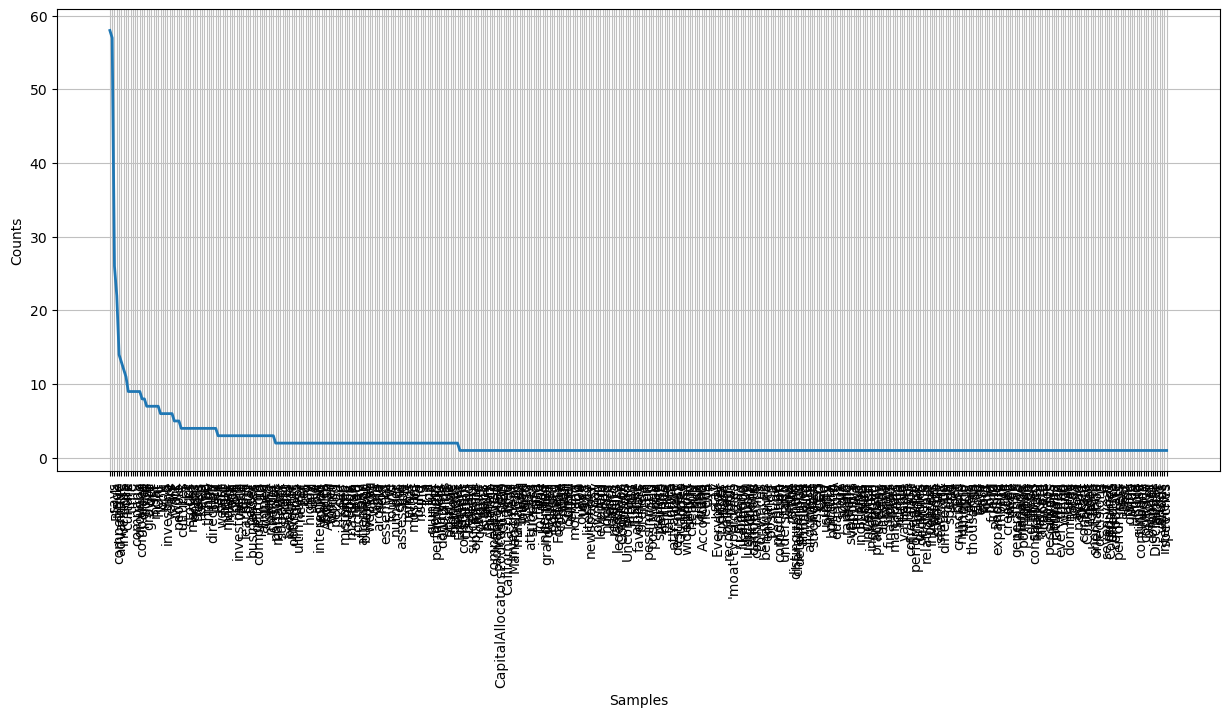

In [44]:
plt.figure(figsize = (15,6))
word_freq.iloc[0].plot()
plt.show()

In [45]:
rd = raw_data_original.copy()

In [46]:
import time
start = time.time()
#rd['Headlines'] = rd['Headlines'].astype(str)
#rd['Summary'] = rd['Summary'].astype(str)
rd['Article'] = rd['Article'].astype(str)

#nlp_preprocessing(rd,'Headlines')
#nlp_preprocessing(rd,'Summary')
nlp_preprocessing(rd,'Article')

#apply_lemmatize(rd,'Headlines')
#apply_lemmatize(rd,'Summary')
apply_lemmatize(rd,'Article')

end = time.time()
print('Execution time:',end-start)

Execution time: 13.535400390625


In [47]:
article = rd['Article']
total_docs = len(article)

In [48]:
def frequency(x):
    x = [i for i in x if len(i)!=0]
    prob = []
    freqDist = FreqDist(x)
    words = list(freqDist.keys())
    for i in freqDist.values():

        prob.append(i/len(x))
    return dict(zip(x,prob))

In [49]:
#Combined all the rows into a single document to create a word bank of all unique words in the documents.
def combine_rows(x):
    s = ''
    for i in x:
        if len(i)!=0:
            s+=i
            s+=' '
    return s

In [50]:
full_doc = ''
for i in article.apply(combine_rows):
    full_doc+=i

unique_words = set(full_doc.split())

In [51]:
probs_article = article.apply(frequency)

In [52]:
each_article_prob = list(probs_article)

In [53]:
n_docs_idf = {}
for i in unique_words:
    count = 0
    for j in article:
        for k in j:
            if len(k)!=0:
                if k.strip()==i:
                    count+=1
    n_docs_idf.setdefault(i,np.log(len(article)/count))

In [54]:
# First, define the each_sentence_prob variable
each_sentence_prob = []  # Initialize with your term frequency data
# For example: each_sentence_prob = [{word1: freq1, word2: freq2}, {word1: freq3, ...}, ...]

# Also make sure n_docs_idf is defined
n_docs_idf = {}  # This should contain your IDF values for each term

# Now the original code will work
tfidf_calc = each_sentence_prob.copy()# ai
tfidf = []
for j in range(len(tfidf_calc)):
    abc = []
    for keys,tf_ in tfidf_calc[j].items():
        try:
            abc.append(tf_*n_docs_idf[keys]) #TF-IDF operation. TF * IDF
        except:
            pass
    tfidf.append(abc)

In [55]:
tfidf_output = pd.DataFrame(tfidf).fillna(0)
tfidf_output.to_csv('TFIDF.csv',index = False)

In [56]:
tfidf_output

""


In [58]:
data = pd.read_csv('TFIDF_articles.csv')
data

,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,39,40,41,42,43
0,0.152884,-0.164290,-0.150491,0.250633,0.045307,0.067249,0.350670,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.247465,-0.063997,0.107676,0.140187,0.220876,0.049161,0.137734,0.056213,0.283025,0.104012,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.051838,0.040785,0.008180,0.095785,0.014857,0.034474,0.030821,0.142123,0.194991,0.174216,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.111434,-0.056344,0.500837,0.051368,0.327550,0.197705,0.197158,0.065582,0.616361,0.156240,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.154413,0.491143,0.192828,0.417746,0.122463,0.348431,0.137289,0.381282,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1625,0.358774,0.324986,-0.010008,0.220950,-0.095836,-0.087786,0.050426,0.171566,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1626,0.149603,-0.024046,0.067160,0.167981,-0.060528,-0.110888,0.042423,0.050705,0.079049,0.024776,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1627,0.161097,0.113027,0.066861,0.300502,0.300502,0.259956,0.096837,0.182933,0.129208,0.085299,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1628,0.197252,0.143147,0.035727,0.255989,0.114429,0.075842,-0.049167,-0.021319,0.120263,0.168455,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


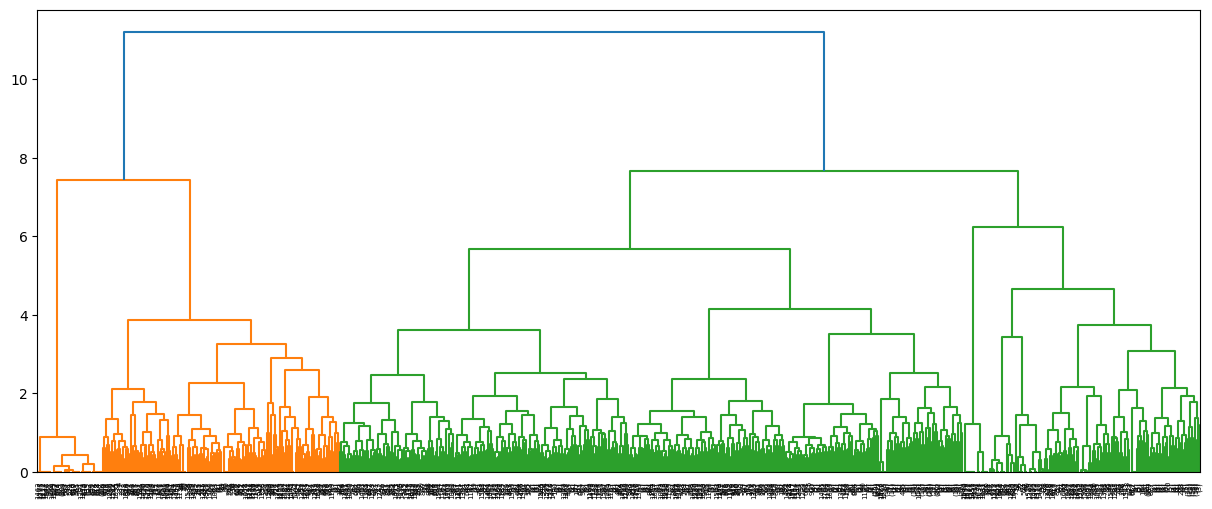

In [59]:
import scipy.cluster.hierarchy as sch
plt.figure(figsize = (15,6))
sch.dendrogram(sch.linkage(data,'ward'),p = 10,truncate_mode = 'level')
plt.show()

In [60]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(data)
csum = np.cumsum(pca.explained_variance_ratio_)
np.where(csum>0.95)[0][1]

np.int64(17)

In [61]:
pca = PCA(n_components = 17)
X_pca = pd.DataFrame(pca.fit_transform(data))

In [62]:
# Import the KMeans class from sklearn.cluster
from sklearn.cluster import KMeans

# Now use KMeans as before
km = KMeans(n_clusters=2)
km.fit(X_pca)
target_km = pd.Series(km.predict(X_pca))

In [63]:
target_km.value_counts()

1    1282
0     348
Name: count, dtype: int64

In [64]:
from sklearn.cluster import AgglomerativeClustering
hca = AgglomerativeClustering(n_clusters = 2)
hca.fit(X_pca)
target_hca = pd.Series(hca.labels_,name = 'Sentiment')

In [65]:
X_pca.shape

(1630, 17)

In [66]:
dat = pd.DataFrame([i for i in collection.find()])
dat.drop('_id',axis = 1,inplace = True)
dat_orig = dat.drop_duplicates()

In [67]:
data_w_target = pd.concat((dat[['Date','Article']],target_hca),axis = 1).dropna()

In [68]:
data_w_target['Sentiment'] = data_w_target['Sentiment'].map({0:'Positive',1:'Negative'})

In [69]:
data_w_target[data_w_target['Sentiment']=='Negative'].iloc[0,1][:1000]

'There are green shoots visible in various sectors of the economy and the country is already looking at a \'V-shaped\' recovery, Minister of State for Finance and Corporate Affairs Anurag Thakur said on Saturday. "India is already looking at \'V-shaped\' recovery. Along with the green shoots in various sectors, in the month of February, FPI inflows were Rs 25,787 crore," Thakur said at a virtual conclave organised by the Institute of Actuaries of India. \n\n After two consecutive quarters of contraction, the country\'s gross domestic product (GDP) entered into a positive territory with a growth of 0.4 per cent in the October-December quarter of the current fiscal, according to the data released by the National Statistical Office (NSO) in February. \n\n Thakur said the country\' foreign exchange reserves, which have been steadily increasing over the last few months, had touched all time high at USD 590 billion in January 2021. \n\n He said the accretion to the forex reserves in the last

In [70]:
data_w_target[data_w_target['Sentiment']=='Negative'].iloc[1,1][:1000]

'MUMBAI: CLSA expects Prestige Estates Projects to get re-rated on a stronger balance sheet and reduction in leverage. The brokerage has maintained a buy on the stock and raised target price to Rs 360 from Rs 340.\n\nPrestige Estates has concluded phase one of its deal with Blackstone which involves transfer of annuity assets with enterprise value of about Rs 7,470 crore out of the total deal EV of Rs 9,160 crore.\n\nCLSA said this is estimated to result in transfer of debt of Rs 4,590 crore out of Prestige Estate\'s balance sheet and net proceeds of Rs 2,100 crore net of taxes to Prestige.\n\nThe brokerage expects the net debt to decline to Rs 1,900 crore from a pre-deal level of Rs 8,500 crore.\n\n"Management plans to use net proceeds for capex and new project acquisition. With large, mature assets being transferred in this deal, the portfolio churn is likely to be value-accretive," said CLSA.\n\n"With leverage concerns addressed and improved outlook on growth driven by adequate liqu

In [71]:
data_w_target[data_w_target['Sentiment']=='Negative'].iloc[2,1][:1000]

"Shares of ACC Ltd. rose 1.46 per cent to Rs 1808.3 in Friday's trade. It hit an intraday high of Rs 1848.0 and low of Rs 1802.25, respectively, during the day. \n\n The stock quoted a 52-week high price of Rs 1893.8 and low of Rs 895.5. \n\n As of 02:02PM (IST), the counter saw total traded volume of 16,599 shares with a traded value of Rs 3.01 crore, according to NSE. \n\n The stock had closed at Rs 1835.05 in the previous session. \n\n The scrip has advanced 2.37 per cent in the past one month till date, while the benchmark BSE Sensex has gained 4.33 per cent during the same period. \n\n According to exchange data, the stock traded at a price-to-earnings (P/E) multiple of 23.79 while price-to-book ratio stood at 2.35. A higher P/E ratio shows that investors are willing to pay a higher price for per rupee earnings given by the stock because of better future growth expectations. The price-to-book value indicates the inherent value of a company and it reflects the price investors are r

In [72]:
data_w_target[data_w_target['Sentiment']=='Negative'].iloc[3,1][:1000]

"Shares of Vedanta Ltd. traded 3.09 per cent up at Rs 219.5 at around 01:46PM (IST) on Friday. The stock had closed at Rs 226.5 in the previous session. Equity benchmark Sensex traded 379.05 points lower at 50900.46 around the same time. \n\n\n The scrip has climbed 174.89 per cent in the last one year till date, while the 30-share index has gained 23.68 per cent during the same period. \n\n The stock's 52-week high price stood at Rs 229.65 and the 52-week low price at Rs 60.3. \n\n Trading volume on the counter stood at 479,685 shares, while it quoted a price-to-earnings ratio of -11.16, an EPS value of -19.81 and a price-to-book value of 0.44. In the Nifty50 pack, 12 stocks traded in the green, while 38 stocks were in the red. \n\n\n Promoter/FII Holding  Promoters held 0.0 per cent stake in the company as of 31-Dec-2020, while FII and MF ownership stood at 16.06 per cent and 5.56 per cent, respectively. \n\n\n Key Financials  For the quarter ended 31-Dec-2020, the company reported c

In [73]:
data_w_target[data_w_target['Sentiment']=='Positive'].iloc[0,1][:1000]

"Eminent portfolio manager Paul Black says the best way investors can ensure consistent wealth creation is by betting on good growth companies with superior culture that have a strong competitive advantage over peers.\n\nBlack says in order to become a successful growth investor, one should be optimistic about the future because optimists can conquer great heights.\n\n“If you look back through history, optimists are the ones who ultimately get it right. Buffett says it all the time: never bet against America. I'd say never bet against great growth companies with superior cultures and the ones that are highly competitively advantaged,” Black said in an interview with CapitalAllocatorsPodcast.com.\n\nPaul Black is the co-CEO and fund manager at the California-based WCM Investment Management, which manages over $42 billion in investor money. He joined the firm in 1989 and attributes its investing success to a lot of hard work and also good fortune.\n\n\nHow Black got interested in stocks\

In [74]:
data_w_target[data_w_target['Sentiment']=='Positive'].iloc[1,1][:1000]

'In a truncated week, Indian equities failed to take any directional cues and the indices went all over the place in the four trading sessions, before ending the week with a modest gain.\n\nThe start of the week was volatile with Nifty trading in a wide range. However, the first part of the week saw a wider trading range of over 634 points, while the previous four session saw Nifty oscillate in a relatively narrower 416-point range.\n\nBroadly speaking, Nifty continued to face resistance at the lower top formed on the daily charts, which has the 15,250-15,300 zone offering stiff resistance. Following a sharp correction seen on the last trading day of the week, the headline index ended with a net gain of 92.85 points, or 0.62 per cent.\n\nDespite improving market breadth, Nifty confirmed its slippage into a broad-range consolidation. On the higher side, the 15,250-15,300 zone continued to act as stiff resistance. Unless this zone is taken out, Nifty will struggle to see any meaningful u

In [75]:
data_w_target[data_w_target['Sentiment']=='Positive'].iloc[2,1][:1000]

'Following are five big themes likely to dominate thinking of investors and traders in the coming week.\n\n\n1/ TIME TO PUSH BACK?\nAfter a stunning selloff in U.S. Treasuries took benchmark 10-year yields above 1.6%, the highest in a year, the March 16-17 Federal Reserve meeting will be watched closely for hints policymakers are concerned about yields, asset bubbles and inflation.\n\nA repricing of market interest rate expectations to anticipate a Fed hike as early as late 2022 is at odds with the Fed’s aim of keeping rates unchanged until the end of 2023. The Fed has appeared unperturbed so far by higher bond yields, but it may feel it’s time to push back against those rate-hike bets.\n\nIt is also expected to release fresh forecasts on economic growth as vaccines are distributed.\n\n\n2/ MIXING MESSAGES AT BOJThe central bank which pioneered yield curve control faces one of its toughest policy reviews on March 18-19.\n\nThe Bank of Japan will likely insert clearer guidance in its st

In [76]:
data_w_target[data_w_target['Sentiment']=='Positive'].iloc[4,1][:1000]

'NEW DELHI: Tata group firm Titan on Friday said it has completed its exit from joint venture Montblanc India Retail, which operates retail boutiques in the country for Montblanc products. Last year on October 8, Titan had announced its exit from the five-year joint venture with the luxury firm.\n\n "... we hereby inform you that, on 12th March 2021, the Company has completed its exit from Montblanc India Retail Private Limited (MB India). Consequently, MB India ceases to be an associate/ JV Company of the Company with effect from March 12, 2021," Titan said in a regulatory filing. \n\n Titan held 49 per cent equity stake in Montblanc India Retail Private Limited.\n'

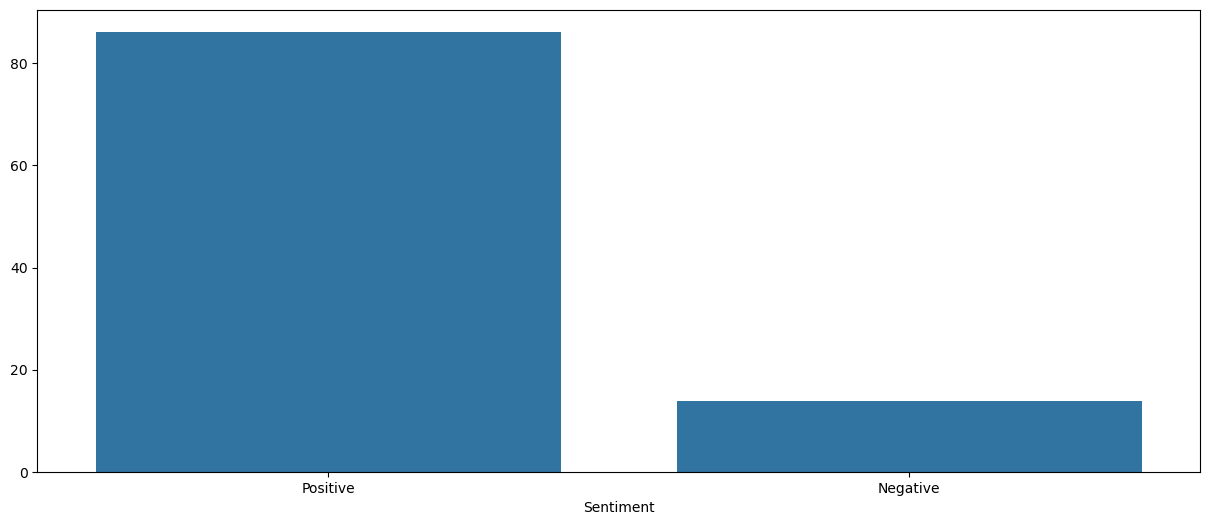

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

temp = data_w_target['Sentiment'].value_counts()/len(data_w_target)*100

plt.figure(figsize=(15,6))
sns.barplot(x=temp.index, y=temp.values)   # use keywords
plt.show()


In [78]:
raw_data_original.tail(1)

,Date,Headlines,Summary,Article,Close,0,1,2,3,4,...,34,35,36,37,38,39,40,41,42,43
3430,"September 20,2025","Gainers & Losers: Adani Power, Urban Company a...",,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
raw_data_original.head(1)

,Date,Headlines,Summary,Article,Close,0,1,2,3,4,...,34,35,36,37,38,39,40,41,42,43
0,"March 13,2021",Paul Black's 3 thumb rules to pick great wealt...,Black says in order to become a successful gro...,Eminent portfolio manager Paul Black says the ...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
nifty_price = pd.read_csv('NSE Prices Jan-13 to Mar 19th - Sheet1.csv').iloc[21:,:]
nifty_price['Date'] = nifty_price['Date'].apply(lambda x: x.split()[0])

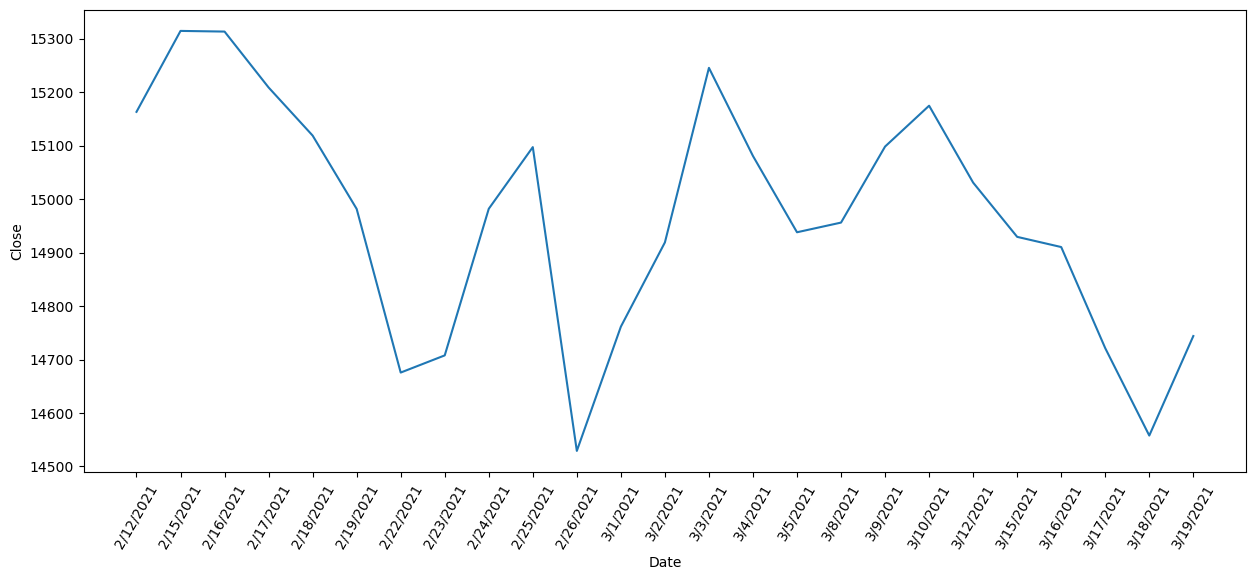

In [81]:
plt.figure(figsize=(15,6))
sns.lineplot(x=nifty_price['Date'], y=nifty_price['Close'])
plt.xticks(rotation=60)
plt.show()


In [86]:
# ===================== CELL 1: SCRAPE NEWS -> df_web =====================

# Scrapes finance news via RSS (Reuters + Google News query) and prepares

# a test DataFrame `df_web` with:

#   ['date','title','summary','text','link','source','_y_pseudo']

# `_y_pseudo` are weak labels from a tiny finance lexicon (for proxy eval).
 
import re, time, gc

import pandas as pd

from datetime import datetime, timezone

from urllib.request import Request, urlopen

from urllib.error import URLError, HTTPError

import xml.etree.ElementTree as ET
 
# ----------------------------- Config -------------------------------------------

GOOGLE_NEWS_RSS = (

    "https://news.google.com/rss/search?"

    "q=Sensex+OR+Nifty+OR+%22stock+market%22&"

    "hl=en-IN&gl=IN&ceid=IN:en"

)
 
RSS_SOURCES = [

    "https://feeds.reuters.com/reuters/businessNews",

    "https://feeds.reuters.com/reuters/marketsNews",

    GOOGLE_NEWS_RSS,

]

MAX_ITEMS_PER_FEED = 50  # set None to take all
 
# ----------------------------- Helpers ------------------------------------------

def _fetch(url, timeout=12):

    """Fetch bytes with a browser-like User-Agent; return None on error."""

    try:

        req = Request(url, headers={"User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X) AppleWebKit/537.36 "

                                                  "(KHTML, like Gecko) Chrome/118.0 Safari/537.36"})

        with urlopen(req, timeout=timeout) as resp:

            return resp.read()

    except (HTTPError, URLError, TimeoutError) as e:

        print(f"⚠️  Fetch failed for {url}: {e}")

        return None
 
_TAGS_RE = re.compile(r"<[^>]+>")

_WS_RE   = re.compile(r"\s+")
 
def _strip_html(s: str) -> str:

    s = _TAGS_RE.sub(" ", s or "")

    s = _WS_RE.sub(" ", s).strip()

    return s
 
def _parse_rss(xml_bytes):

    """Parse RSS/Atom into a list of dicts: title, summary, link, published."""

    if not xml_bytes:

        return []

    try:

        root = ET.fromstring(xml_bytes)

    except ET.ParseError:

        return []
 
    items = []

    # RSS 2.0

    channel = root.find("channel")

    if channel is not None:

        for it in channel.findall("item"):

            items.append({

                "title": (it.findtext("title") or "").strip(),

                "summary": (it.findtext("description") or "").strip(),

                "link": (it.findtext("link") or "").strip(),

                "published": (it.findtext("pubDate") or "").strip(),

            })

    else:

        # Atom

        ns = "{http://www.w3.org/2005/Atom}"

        for it in root.findall(f".//{ns}entry"):

            link_el = it.find(f"{ns}link")

            items.append({

                "title": (it.findtext(f"{ns}title") or "").strip(),

                "summary": (it.findtext(f"{ns}summary") or "").strip(),

                "link": (link_el.get("href").strip() if link_el is not None and link_el.get("href") else ""),

                "published": (it.findtext(f"{ns}updated") or "").strip(),

            })
 
    cleaned = []

    for d in items[: (MAX_ITEMS_PER_FEED or len(items))]:

        title = _strip_html(d.get("title", ""))

        summ  = _strip_html(d.get("summary", ""))

        if not (title or summ):

            continue

        cleaned.append({

            "title": title,

            "summary": summ,

            "link": d.get("link", ""),

            "published": d.get("published", ""),

        })

    return cleaned
 
def _gather_news():

    rows = []

    for src in RSS_SOURCES:

        xml_bytes = _fetch(src)

        items = _parse_rss(xml_bytes)

        for it in items:

            text = (it["title"] + ". " + it["summary"]).strip()

            # Best-effort date parsing; fall back to UTC now.

            dt = None

            for fmt in ("%a, %d %b %Y %H:%M:%S %Z", "%Y-%m-%dT%H:%M:%SZ", "%Y-%m-%dT%H:%M:%S%z"):

                try:

                    dt = datetime.strptime(it["published"], fmt)

                    break

                except Exception:

                    pass

            if dt is None:

                dt = datetime.now(timezone.utc)

            rows.append({

                "date": dt.strftime("%Y-%m-%d"),

                "title": it["title"],

                "summary": it["summary"],

                "text": text,

                "link": it["link"],

                "source": src,

            })

        time.sleep(0.5)  # be polite

    if not rows:

        print("⚠️  No articles scraped. Using a tiny fallback set to avoid errors.")

        rows = [

            {"date":"2025-01-01","title":"Market rally on positive earnings","summary":"Banks lead gains.","text":"Market rally on positive earnings. Banks lead gains.","link":"", "source":"fallback"},

            {"date":"2025-01-01","title":"Sensex slips amid global risk-off","summary":"IT stocks drag indices lower.","text":"Sensex slips amid global risk-off. IT stocks drag indices lower.","link":"", "source":"fallback"},

            {"date":"2025-01-02","title":"Rupee strengthens as crude eases","summary":"Energy import costs fall.","text":"Rupee strengthens as crude eases. Energy import costs fall.","link":"", "source":"fallback"},

        ]

    dfw = pd.DataFrame(rows).drop_duplicates(subset=["title","summary","link"])

    return dfw
 
def _lexicon_label_series(texts: pd.Series) -> pd.Series:

    """Weak pseudo-labels via tiny finance lexicon (0=neg, 1=pos)."""

    POS = {"gain","surge","upbeat","profit","beat","strong","growth","rally","bullish","upgrade",

           "outperform","record","robust","improve","higher","boost","optimism","advance","climb","jump"}

    NEG = {"loss","slump","downgrade","weak","miss","decline","risk","bearish","fall","plunge",

           "cut","shortfall","slowdown","concern","lower","drop","crisis","volatility","selloff","slide"}

    out = []

    for s in texts.fillna("").astype(str):

        ws = re.findall(r"[A-Za-z']+", s.lower())

        score = sum(w in POS for w in ws) - sum(w in NEG for w in ws)

        out.append(1 if score >= 0 else 0)

    return pd.Series(out, index=texts.index, dtype=int)
 
# ----------------------------- Run scrape + pseudo labels ------------------------

df_web = _gather_news()

df_web["text"] = df_web["text"].astype(str).fillna("")

df_web["_y_pseudo"] = _lexicon_label_series(df_web["text"])
 
print(f"Scraped articles: {len(df_web)}")

try:

    display(df_web[["date","title","summary","link"]].head(8))

except Exception:

    print(df_web[["date","title","summary","link"]].head(8))
 
gc.collect()

# ================================================================================ 

 # ===================== CELL 2: PREDICT & SCORE ON df_web =====================
# Uses your *trained* FinBERT (trainer-free setup) to:
#  - predict on `df_web["text"]`,
#  - compare vs `_y_pseudo` (proxy),
#  - save predictions to CSV.
 
import numpy as np, torch, gc
 
# Preconditions: model & tokenizer from your training cell, and df_web from Cell 1
assert "model" in globals(), "❌ Model not found. Run your training cell first."
assert "tokenizer" in globals(), "❌ Tokenizer not found. Run your training cell first."
assert "df_web" in globals(), "❌ df_web not found. Run Cell 1 to scrape news first."
 
device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()
MAX_LEN = int(globals().get("MAX_LEN", 256))
 
def _predict_proba_texts(texts, batch_size=32, max_len=256):
    """Return softmax probabilities (N, C) with your trained FinBERT."""
    chunks, out = range(0, len(texts), batch_size), []
    for i in chunks:
        batch = ["" if t is None else str(t) for t in texts[i:i+batch_size]]
        enc = tokenizer(batch, truncation=True, max_length=max_len, padding=True, return_tensors="pt")
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            logits = model(**enc).logits
            probs  = torch.softmax(logits, dim=-1).cpu().numpy()
        out.append(probs); del enc, logits
    return np.vstack(out) if out else np.zeros((0, getattr(model.config, "num_labels", 2)))
 
texts = df_web["text"].astype(str).fillna("").tolist()
proba = _predict_proba_texts(texts, batch_size=32, max_len=MAX_LEN)
 
# Defensive: ensure 2 columns (neg/pos)
if proba.ndim == 1:
    proba = proba.reshape(-1, 1)
if proba.shape[1] == 1:
    proba = np.hstack([proba, 1.0 - proba])
elif proba.shape[1] < 2:
    proba = np.pad(proba, ((0,0),(0, 2 - proba.shape[1])), mode="constant", constant_values=0.0)
 
pred = proba.argmax(axis=1)
 
# Attach predictions
df_web["finbert_proba_neg"] = proba[:, 0]
df_web["finbert_proba_pos"] = proba[:, 1]
df_web["finbert_pred"]      = pred
 
# Proxy metrics vs pseudo-labels (binary: 1=positive)
if "_y_pseudo" in df_web.columns:
    y_true = df_web["_y_pseudo"].to_numpy().astype(int)
    y_pred = pred.astype(int)
 
    acc = float((y_pred == y_true).mean())
    tp = int(((y_pred==1) & (y_true==1)).sum())
    fp = int(((y_pred==1) & (y_true==0)).sum())
    fn = int(((y_pred==0) & (y_true==1)).sum())
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1        = (2*precision*recall)/(precision+recall) if (precision+recall) else 0.0
 
    print("\n================ WEB TEST (Proxy vs pseudo-labels) ================")
    print(f"Articles: {len(df_web)}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    print("===================================================================\n")
else:
    print("⚠️  `_y_pseudo` not found; skipping proxy metrics.")
 
# Preview and save
cols_show = ["date","title","summary","link","finbert_pred","finbert_proba_pos"]
try:
    display(df_web[cols_show].head(8))
except Exception:
    print(df_web[cols_show].head(8))
 
out_path = "web_test_predictions.csv"
df_web.to_csv(out_path, index=False)
print(f"Saved predictions -> {out_path}")
 
gc.collect()
# =============================================================================== 

⚠️  Fetch failed for https://feeds.reuters.com/reuters/businessNews: <urlopen error [Errno 8] nodename nor servname provided, or not known>
⚠️  Fetch failed for https://feeds.reuters.com/reuters/marketsNews: <urlopen error [Errno 8] nodename nor servname provided, or not known>
Scraped articles: 50


,date,title,summary,link
0,2026-04-02,"Stock Market Crash Today Highlights: Nifty, Se...","Stock Market Crash Today Highlights: Nifty, Se...",https://news.google.com/rss/articles/CBMinwJBV...
1,2026-04-02,Sensex Today | Nifty 50 | Stock Market Live Up...,Sensex Today | Nifty 50 | Stock Market Live Up...,https://news.google.com/rss/articles/CBMijgJBV...
2,2026-04-02,Investors Lose Rs 10 Lakh Crore In An Hour. He...,Investors Lose Rs 10 Lakh Crore In An Hour. He...,https://news.google.com/rss/articles/CBMizwFBV...
3,2026-04-03,"Stock market holiday today: BSE, NSE to remain...","Stock market holiday today: BSE, NSE to remain...",https://news.google.com/rss/articles/CBMi1wFBV...
4,2026-04-02,"Sensex down 1,000 points: Why is the stock mar...","Sensex down 1,000 points: Why is the stock mar...",https://news.google.com/rss/articles/CBMi0AFBV...
5,2026-04-02,"Stock market today: Nifty50 tops 22,700, BSE S...","Stock market today: Nifty50 tops 22,700, BSE S...",https://news.google.com/rss/articles/CBMitAJBV...
6,2026-04-02,"Sensex, Nifty today: Why stock market is falli...","Sensex, Nifty today: Why stock market is falli...",https://news.google.com/rss/articles/CBMiyAFBV...
7,2026-04-02,Why Is Share Market Falling Today? Know Key Fa...,Why Is Share Market Falling Today? Know Key Fa...,https://news.google.com/rss/articles/CBMi3wFBV...



================ WEB TEST (Proxy vs pseudo-labels) ================
Articles: 50
Accuracy : 0.9400
Precision: 0.9400 | Recall: 1.0000 | F1: 0.9691



,date,title,summary,link,finbert_pred,finbert_proba_pos
0,2026-04-02,"Stock Market Crash Today Highlights: Nifty, Se...","Stock Market Crash Today Highlights: Nifty, Se...",https://news.google.com/rss/articles/CBMinwJBV...,1,0.835214
1,2026-04-02,Sensex Today | Nifty 50 | Stock Market Live Up...,Sensex Today | Nifty 50 | Stock Market Live Up...,https://news.google.com/rss/articles/CBMijgJBV...,1,0.839153
2,2026-04-02,Investors Lose Rs 10 Lakh Crore In An Hour. He...,Investors Lose Rs 10 Lakh Crore In An Hour. He...,https://news.google.com/rss/articles/CBMizwFBV...,1,0.847447
3,2026-04-03,"Stock market holiday today: BSE, NSE to remain...","Stock market holiday today: BSE, NSE to remain...",https://news.google.com/rss/articles/CBMi1wFBV...,1,0.859554
4,2026-04-02,"Sensex down 1,000 points: Why is the stock mar...","Sensex down 1,000 points: Why is the stock mar...",https://news.google.com/rss/articles/CBMi0AFBV...,1,0.849765
5,2026-04-02,"Stock market today: Nifty50 tops 22,700, BSE S...","Stock market today: Nifty50 tops 22,700, BSE S...",https://news.google.com/rss/articles/CBMitAJBV...,1,0.836143
6,2026-04-02,"Sensex, Nifty today: Why stock market is falli...","Sensex, Nifty today: Why stock market is falli...",https://news.google.com/rss/articles/CBMiyAFBV...,1,0.873481
7,2026-04-02,Why Is Share Market Falling Today? Know Key Fa...,Why Is Share Market Falling Today? Know Key Fa...,https://news.google.com/rss/articles/CBMi3wFBV...,1,0.868743


Saved predictions -> web_test_predictions.csv


0

In [87]:
# ==== NLP METRICS: compute + export (robust, binary/multiclass-safe) ====
import os, json, numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.preprocessing import LabelEncoder

def _to_numpy(x):
    try:
        import torch
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
    except Exception:
        pass
    try:
        import pandas as pd
        if isinstance(x, (pd.Series, pd.DataFrame)):
            x = x.squeeze()
            return x.to_numpy()
    except Exception:
        pass
    return np.asarray(x)

def _pick(names):
    g = globals()
    for n in names:
        if n in g:
            arr = _to_numpy(g[n])
            if arr is None: 
                continue
            arr = np.atleast_1d(arr)               # wraps scalars
            arr = np.ravel(arr)                    # flatten
            if arr.size > 0:
                return arr
    return None

# Try to find true labels, predicted labels, and optional probabilities
y_true  = _pick(["y_true","y_test","y_valid","y_val","y_gold","labels_true","labels","targets"])
y_pred  = _pick(["y_pred","y_hat","preds","pred_labels","yhat"])
y_proba = _pick(["y_proba","y_prob","probs","prob_scores","y_score","probabilities"])

# If only probabilities available, convert to labels
if y_pred is None and y_proba is not None:
    if y_proba.ndim == 2:
        y_pred = np.argmax(y_proba, axis=1)
    else:
        y_pred = (y_proba >= 0.5).astype(int)

assert y_true is not None and y_pred is not None, "Need y_true and y_pred (or y_proba) in memory."

# If labels are strings/bools, encode them jointly to keep class mapping consistent
if y_true.dtype.kind in "OUSb" or y_pred.dtype.kind in "OUSb":
    le = LabelEncoder()
    y_all = le.fit_transform(np.concatenate([y_true, y_pred]))
    y_true = y_all[:len(y_true)]
    y_pred = y_all[len(y_true):]
    # Also align y_proba if it's 2D and matches class count
    if y_proba is not None and y_proba.ndim == 2 and y_proba.shape[1] != len(le.classes_):
        # size mismatch; drop proba to avoid bad AUC
        y_proba = None

# If y_proba is 2D with >2 columns but predictions are binary, keep argmax
if y_proba is not None and y_proba.ndim == 2 and y_proba.shape[1] > 2 and len(np.unique(y_true)) == 2:
    # reduce to positive-class column using predicted class as proxy if possible
    y_proba = y_proba[:, 1] if y_proba.shape[1] >= 2 else None

# Ensure arrays are 1-D
y_true = np.ravel(np.atleast_1d(y_true))
y_pred = np.ravel(np.atleast_1d(y_pred))
if y_proba is not None:
    y_proba = np.ravel(y_proba) if y_proba.ndim == 1 else y_proba

classes = np.unique(y_true)
n_classes = len(classes)
is_binary = n_classes == 2

metrics_nlp = {
    "task": "classification",
    "n_samples": int(y_true.shape[0]),
    "accuracy": float(accuracy_score(y_true, y_pred))
}

if is_binary:
    metrics_nlp.update({
        "precision": float(precision_score(y_true, y_pred, average="binary", zero_division=0)),
        "recall":    float(recall_score(y_true, y_pred, average="binary", zero_division=0)),
        "f1":        float(f1_score(y_true, y_pred, average="binary", zero_division=0)),
    })
    # Confusion matrix with positive class last is sklearn default; we’ll compute and then map
    cm = confusion_matrix(y_true, y_pred, labels=[1,0])
    tp, fn = int(cm[0,0]), int(cm[0,1])
    fp, tn = int(cm[1,0]), int(cm[1,1])
    metrics_nlp.update({"tp": tp, "fp": fp, "fn": fn, "tn": tn})

    # AUC only if proper proba/score is present
    try:
        if y_proba is not None:
            # If 2D proba (n_samples, 2), use positive column
            if y_proba.ndim == 2 and y_proba.shape[1] == 2:
                y_score = y_proba[:, 1]
            else:
                y_score = y_proba
            metrics_nlp["auc"] = float(roc_auc_score(y_true, y_score))
    except Exception:
        pass
else:
    # Multiclass: macro scores
    metrics_nlp.update({
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro":    float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro":        float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "n_classes": int(n_classes)
    })
    # Confusion matrix for all classes
    cm = confusion_matrix(y_true, y_pred)
    metrics_nlp["confusion_matrix"] = cm.tolist()  # JSON-safe
    # Multiclass AUC not reported unless proper one-vs-rest probabilities are available; skipping for safety.

# Save
os.makedirs("model_outputs", exist_ok=True)
with open("model_outputs/nlp_metrics.json","w") as f:
    json.dump(metrics_nlp, f, indent=2)

print("=== NLP METRICS ===")
for k,v in metrics_nlp.items():
    print(f"{k}: {v}")
print("Saved -> model_outputs/nlp_metrics.json")


=== NLP METRICS ===
task: classification
n_samples: 50
accuracy: 0.94
precision: 0.94
recall: 1.0
f1: 0.9690721649484536
tp: 47
fp: 3
fn: 0
tn: 0
Saved -> model_outputs/nlp_metrics.json
